In [1]:
import os
import subprocess
from pathlib import Path

# Buscar dónde se descargó el dataset de wheel de zarr en /kaggle/input/
input_path = Path("/kaggle/input")
wheel_files = list(input_path.glob("**/*.whl"))

if wheel_files:
    # Instalar desde el archivo .whl local sin usar red (--no-index)
    wheel_dir = wheel_files[0].parent
    print(f"Instalando zarr offline desde: {wheel_dir}")
    subprocess.run(
        [
            "pip",
            "install",
            "--no-index",
            "--find-links",
            str(wheel_dir),
            "zarr",
        ],
        check=True,
    )
else:
    print(
        "⚠️ No se encontraron archivos .whl. Asegúrate de haber añadido el dataset de zarr a Input."
    )

import zarr  # Ahora se importará correctamente sin errores

print("✅ Zarr importado exitosamente de forma offline.")

Instalando zarr offline desde: /kaggle/input/notebooks/ashutoshpal1/zarr-wheels/zarr_wheels
Looking in links: /kaggle/input/notebooks/ashutoshpal1/zarr-wheels/zarr_wheels
Processing /kaggle/input/notebooks/ashutoshpal1/zarr-wheels/zarr_wheels/zarr-3.3.0-py3-none-any.whl
Processing /kaggle/input/notebooks/ashutoshpal1/zarr-wheels/zarr_wheels/donfig-0.8.1.post1-py3-none-any.whl (from zarr)
Processing /kaggle/input/notebooks/ashutoshpal1/zarr-wheels/zarr_wheels/numcodecs-0.16.5-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (from zarr)
✅ Zarr importado exitosamente de forma offline.


In [8]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import gc

from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
from skimage.feature import blob_dog  #Difference of Gaussians
from skimage.filters import gaussian

import imageio.v2 as imageio

In [3]:
# Ruta estándar para la competición
DATA_DIR = Path("/kaggle/input/competitions/biohub-cell-tracking-during-development")

# Comprobar qué archivos y carpetas hay disponibles
for path in DATA_DIR.iterdir():
    print(path.name)

sample_submission.csv
test
train


## 1. EDA

In [4]:
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

# Obtener las rutas de todos los volúmenes .zarr de entrenamiento
train_zarrs = sorted(list(TRAIN_DIR.glob("*.zarr")))
test_zarrs = sorted(list(TEST_DIR.glob("*.zarr")))

print(f"Número de muestras en Train: {len(train_zarrs)}")
print(f"Número de muestras en Test: {len(test_zarrs)}")

# Ver el nombre de las primeras 3 muestras de train
for zarr_path in train_zarrs[:3]:
    print("Muestra train:", zarr_path.name)

Número de muestras en Train: 199
Número de muestras en Test: 4
Muestra train: 44b6_0113de3b.zarr
Muestra train: 44b6_0b24845f.zarr
Muestra train: 44b6_0c582fdc.zarr


In [5]:
# Cargar la primera muestra de entrenamiento
sample_path = train_zarrs[0]

# Abrir el volumen de imagen 3D+t
img_data = zarr.open(sample_path, mode="r")["0"]
print(f"Dataset cargado: {sample_path.name}")
print(f"Dimensiones (T, Z, Y, X): {img_data.shape}")

# Leer el grafo de anotaciones (.geff) correspondiente
geff_path = TRAIN_DIR / f"{sample_path.stem}.geff"
geff_data = zarr.open(geff_path, mode="r")

# Extraer coordenadas de los nodos
nodes_df = pd.DataFrame(
    {
        "node_id": geff_data["nodes/ids"][:],
        "t": geff_data["nodes/props/t/values"][:],
        "z": geff_data["nodes/props/z/values"][:],
        "y": geff_data["nodes/props/y/values"][:],
        "x": geff_data["nodes/props/x/values"][:],
    }
)

print(
    f"Total de centroides anotados en esta muestra: {len(nodes_df)}"
)

Dataset cargado: 44b6_0113de3b.zarr
Dimensiones (T, Z, Y, X): (100, 64, 256, 256)
Total de centroides anotados en esta muestra: 52


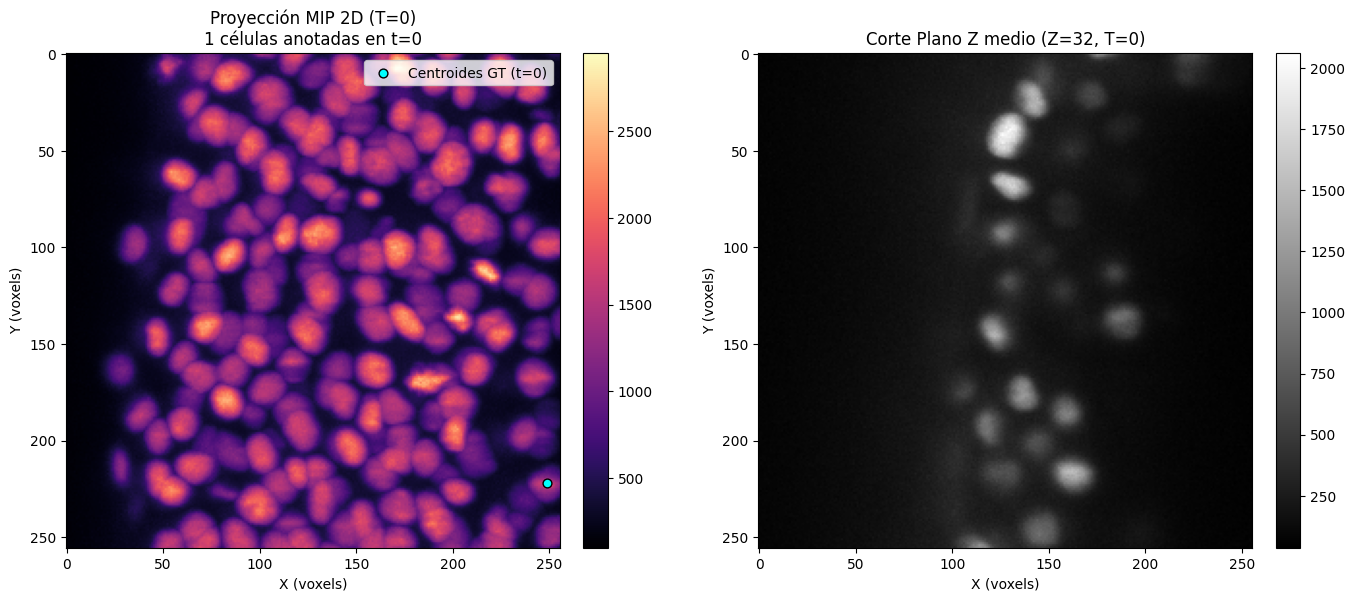

In [6]:
# Tomamos el volumen en el tiempo t = 0 (primer fotograma)
# Dimensiones de frame_t0: (64, 256, 256) -> (Z, Y, X)
frame_t0 = img_data[0]

# 1. Proyección de Máxima Intensidad (MIP) en Z: colapsa la profundidad para ver todas las células
mip_z = np.max(frame_t0, axis=0)

# 2. Corte en el plano medio de profundidad Z (Z = 32)
slice_z_mid = frame_t0[frame_t0.shape[0] // 2]

# 3. Filtrar los centroides anotados que caen exactamente en t = 0
nodes_t0 = nodes_df[nodes_df["t"] == 0]

# --- GRAFICAR LAS VISTAS ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Proyección MIP + Centroides anotados
im1 = axes[0].imshow(mip_z, cmap="magma")
axes[0].scatter(
    nodes_t0["x"],
    nodes_t0["y"],
    c="cyan",
    s=40,
    marker="o",
    edgecolors="black",
    label="Centroides GT (t=0)",
)
axes[0].set_title(
    f"Proyección MIP 2D (T=0)\n{len(nodes_t0)} células anotadas en t=0"
)
axes[0].set_xlabel("X (voxels)")
axes[0].set_ylabel("Y (voxels)")
axes[0].legend(loc="upper right")
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

# Subplot 2: Corte central Z
im2 = axes[1].imshow(slice_z_mid, cmap="gray")
axes[1].set_title(f"Corte Plano Z medio (Z={frame_t0.shape[0] // 2}, T=0)")
axes[1].set_xlabel("X (voxels)")
axes[1].set_ylabel("Y (voxels)")
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## 2. Baseline

In [9]:
OUTPUT_SUBMISSION_PATH = Path("submission.csv")

# Parámetros optimizados
MAX_DISTANCE_VOXELS = 15.0
MIN_SIGMA = 1.2
MAX_SIGMA = 3.5
THRESHOLD = 0.08


def detect_cells_3d_safe(volume_3d):
    """Detección ultra-rápida y segura ante volúmenes vacíos o planos."""
    v_min, v_max = volume_3d.min(), volume_3d.max()

    # Si el volumen es plano (ej. todo ceros o sin contraste)
    if v_max <= v_min:
        return np.empty((0, 3), dtype=np.int16)

    vol_norm = ((volume_3d - v_min) / (v_max - v_min)).astype(np.float32)

    try:
        blobs = blob_dog(
            vol_norm,
            min_sigma=MIN_SIGMA,
            max_sigma=MAX_SIGMA,
            sigma_ratio=1.6,
            threshold=THRESHOLD,
        )
    except Exception:
        return np.empty((0, 3), dtype=np.int16)

    if blobs is None or len(blobs) == 0:
        return np.empty((0, 3), dtype=np.int16)

    return np.round(blobs[:, :3]).astype(np.int16)


def process_dataset_safe(dataset_name, zarr_path):
    """Procesamiento con manejo estricto de casos borde (0 células)."""
    try:
        img_group = zarr.open(zarr_path, mode="r")["0"]
    except Exception as e:
        print(f"Error al abrir {zarr_path}: {e}")
        return [], []

    num_timesteps = img_group.shape[0]
    nodes_list = []
    edges_list = []

    global_node_id = 1
    prev_ids = []
    prev_coords = np.empty((0, 3), dtype=np.float32)

    for t in range(num_timesteps):
        volume_t = img_group[t][:]
        centroids = detect_cells_3d_safe(volume_t)

        curr_ids = []
        curr_coords_list = []

        # 1. Guardar Nodos
        if len(centroids) > 0:
            for z, y, x in centroids:
                nodes_list.append(
                    (
                        dataset_name,
                        "node",
                        global_node_id,
                        t,
                        int(z),
                        int(y),
                        int(x),
                        -1,
                        -1,
                    )
                )
                curr_ids.append(global_node_id)
                curr_coords_list.append([z, y, x])
                global_node_id += 1

        curr_coords = (
            np.array(curr_coords_list, dtype=np.float32)
            if len(curr_coords_list) > 0
            else np.empty((0, 3), dtype=np.float32)
        )

        # 2. Guardar Aristas (Solo si AMBOS fotogramas tienen células)
        if len(prev_ids) > 0 and len(curr_ids) > 0:
            try:
                dist_matrix = cdist(prev_coords, curr_coords)
                row_ind, col_ind = linear_sum_assignment(dist_matrix)

                for r, c in zip(row_ind, col_ind):
                    if dist_matrix[r, c] <= MAX_DISTANCE_VOXELS:
                        edges_list.append(
                            (
                                dataset_name,
                                "edge",
                                -1,
                                -1,
                                -1,
                                -1,
                                -1,
                                prev_ids[r],
                                curr_ids[c],
                            )
                        )
            except Exception:
                pass  # Si falla el matching en un frame defectuoso, continuar

        prev_ids = curr_ids
        prev_coords = curr_coords

    return nodes_list, edges_list


# --- EJECUCIÓN PRINCIPAL CON ESCRITURA EN DISCO ---
test_zarr_paths = sorted(list(TEST_DIR.glob("*.zarr")))

# Crear/Limpiar archivo de salida
if OUTPUT_SUBMISSION_PATH.exists():
    OUTPUT_SUBMISSION_PATH.unlink()

header_written = False
total_rows_written = 0

print(
    f"Iniciando procesado seguro en {len(test_zarr_paths)} datasets del test oculto..."
)

for idx, zarr_path in enumerate(test_zarr_paths):
    dataset_name = zarr_path.stem
    nodes, edges = process_dataset_safe(dataset_name, zarr_path)

    dataset_rows = nodes + edges

    if len(dataset_rows) > 0:
        df_chunk = pd.DataFrame(
            dataset_rows,
            columns=[
                "dataset",
                "row_type",
                "node_id",
                "t",
                "z",
                "y",
                "x",
                "source_id",
                "target_id",
            ],
        )

        # Asignar IDs absolutos según las filas escritas hasta el momento
        df_chunk.insert(
            0, "id", np.arange(total_rows_written, total_rows_written + len(df_chunk))
        )
        total_rows_written += len(df_chunk)

        # Escribir incrementalmente al CSV para NO agotar la memoria RAM
        df_chunk.to_csv(
            OUTPUT_SUBMISSION_PATH,
            mode="a",
            header=not header_written,
            index=False,
        )
        header_written = True

    # Liberar memoria explícitamente
    del nodes, edges
    gc.collect()

# CASO EXTREMO: Si por alguna razón no se detectó nada en ningún dataset, crear un CSV válido vacío
if not header_written or not OUTPUT_SUBMISSION_PATH.exists():
    columns = [
        "id",
        "dataset",
        "row_type",
        "node_id",
        "t",
        "z",
        "y",
        "x",
        "source_id",
        "target_id",
    ]
    pd.DataFrame(columns=columns).to_csv(OUTPUT_SUBMISSION_PATH, index=False)

print(
    f"✅ Proceso finalizado. {total_rows_written} filas escritas en {OUTPUT_SUBMISSION_PATH}."
)

Iniciando procesado seguro en 4 datasets del test oculto...
✅ Proceso finalizado. 118187 filas escritas en submission.csv.
